In [2]:
import jpybinding as jpb
import matplotlib.pyplot as plt
import numpy as np
import scipy as sci
import jclsquant as jcl


## Graphene

In [95]:

def hamiltonian(self,auto_conjugate=True):

    N = self.n1 * self.n2 * self.lattice.norbs

    H_entries = []
    Dx_entries = []
    Dy_entries = []

    S = np.zeros((N, len(self.lattice.a1)), dtype=float)
    Omega=np.linalg.norm(np.cross(self.n1*self.lattice.a1,self.n2*self.lattice.a2))

    def cell_index(ix, iy):
        return (iy * self.n1 + ix) * self.lattice.norbs

    # ----------------------------------------------------
    # Onsites + orbital positions
    # ----------------------------------------------------
    for ix in range(self.n1):
        for iy in range(self.n2):

            R = ix * self.lattice.a1 + iy * self.lattice.a2
            offset = cell_index(ix, iy)

            for sub in self.lattice.sublattices:

                pos = R + np.asarray(sub["position"], dtype=float)
                inds = self.lattice.sub_index_orb[sub["name"]]

                onsite = np.asarray(sub["onsite"])

                if onsite.ndim == 0 or onsite.ndim == 1 :
                    onsite = onsite.reshape((1, 1))

                for i, oi in enumerate(inds):
                    S[offset + oi] = pos
                    for j, oj in enumerate(inds):
                        H_entries.append((offset + oi,offset + oj,onsite[i, j]))
  

    # ----------------------------------------------------
    # Hoppings
    # ----------------------------------------------------
    for ix in range(self.n1):
        for iy in range(self.n2):

            offset1 = cell_index(ix, iy)

            Ri = ix * self.lattice.a1 + iy * self.lattice.a2

            for hop in self.lattice.hoppings:

                dx, dy = hop["relative_index"]

                jx = (ix + dx) % self.n1
                jy = (iy + dy) % self.n2

                offset2 = cell_index(jx, jy)

                from_inds = self.lattice.sub_index_orb[hop["from"]]
                to_inds = self.lattice.sub_index_orb[hop["to"]]

                t = np.asarray(hop["energy"], dtype=np.complex128)
                if t.ndim == 0:
                    t = t.reshape((1, 1))

                sub_from = self.lattice.sublattices[
                    self.lattice.sub_index_sml[hop["from"]]
                ]
                sub_to = self.lattice.sublattices[
                    self.lattice.sub_index_sml[hop["to"]]
                ]

                r_from = Ri + np.asarray(sub_from["position"], dtype=float)
                r_to = (
                    Ri
                    + dx * self.lattice.a1
                    + dy * self.lattice.a2
                    + np.asarray(sub_to["position"], dtype=float)
                )

                dr = r_to - r_from


                for i, oi in enumerate(from_inds):
                    for j, oj in enumerate(to_inds):

                            
                        H_entries.append((offset2+oj, offset1+oi, t[j,i]))

                        Dx_entries.append((offset2 + oj, offset1 + oi,  dr[0]))

                        Dy_entries.append((offset2 + oj, offset1 + oi,  dr[1]))
                        
                        if auto_conjugate is True:
                            H_entries.append(( offset1+oi,offset2+oj, t[j,i].conjugate()))
                            Dx_entries.append((offset1 + oi, offset2 + oj, -dr[0]))
                            Dy_entries.append((offset1 + oi, offset2 + oj, -dr[1]))




    def build_csr(entries):
        rows = np.fromiter((e[0] for e in entries), dtype=np.int32)
        cols = np.fromiter((e[1] for e in entries), dtype=np.int32)
        data = np.fromiter((e[2] for e in entries), dtype=np.asarray(entries[0][2]).dtype)
        return sci.sparse.coo_matrix((data, (rows, cols)), shape=(N, N)).tocsr()


    H = build_csr(H_entries)
    
    Dx = build_csr(Dx_entries)

    Dy = build_csr(Dy_entries)

    return H, S, Omega, Dx, Dy

In [4]:
m=0
a = 0.24595   # [nm] unit cell length
a_cc = 0.142  # [nm] carbon-carbon distance
t=-2.7
lat=jpb.Lattice(a1=[a, 0],a2=[a/2, a/2 * np.sqrt(3)])

lat.add_sublattices(('A', [0, -a_cc/2],m),
                    ('B', [0,  a_cc/2],-m)
)

lat.add_hoppings(
    # inside the main cell
    ([0,  0], 'A', 'B', t),
    # between neighboring cells
    ([1, -1], 'A', 'B', t),
    ([0, -1], 'A', 'B', t)
)






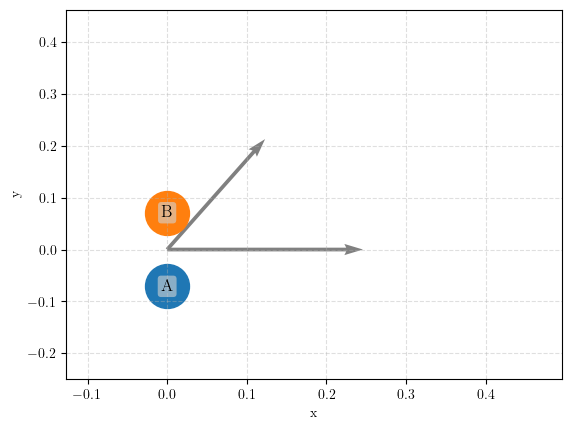

In [5]:
lat.plot()

In [6]:
model=jpb.Model(lat,'real',128)

H,S,Omega,Vx,Vy=hamiltonian(model)
print(H.shape[0])


32768


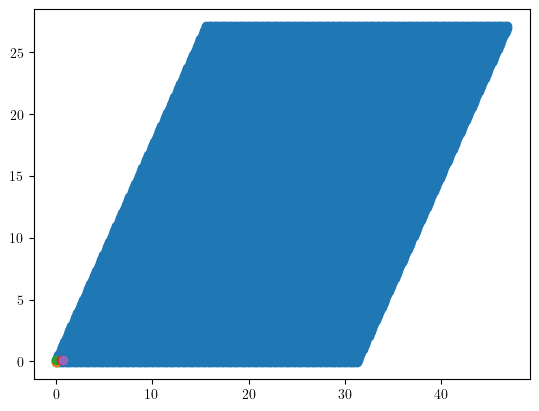

In [7]:
plt.scatter(S[:,0],S[:,1])
plt.scatter(S[0,0],S[0,1])
plt.scatter(S[1,0],S[1,1])
plt.scatter(S[5,0],S[5,1])
plt.scatter(S[7,0],S[7,1])

In [8]:
print(Vx[0,1])
print(H[0,1])
print(Vy[0,1])


0.0
(-2.7+0j)
-0.142


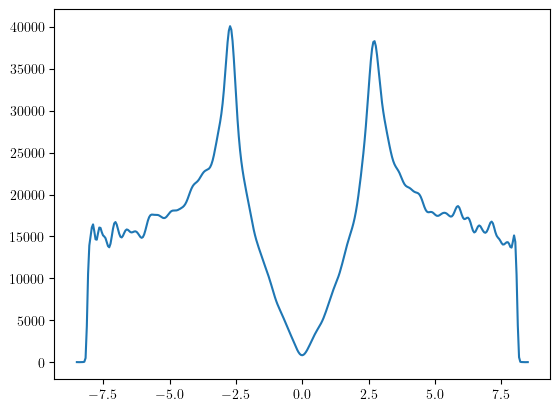

In [9]:
H_ell=jcl.ell_matrix(H)

dos=jcl.kpm_dos(H_ell)

plt.plot(dos[:,0],dos[:,1])


Fermi sea/Full computation, you should integrate this option to obtain the conductivity.


Time it took in the recursion : 1.8985578650026582[s]
Starting to sum table
Time it took in the summation : 0.10315720200014766[s]


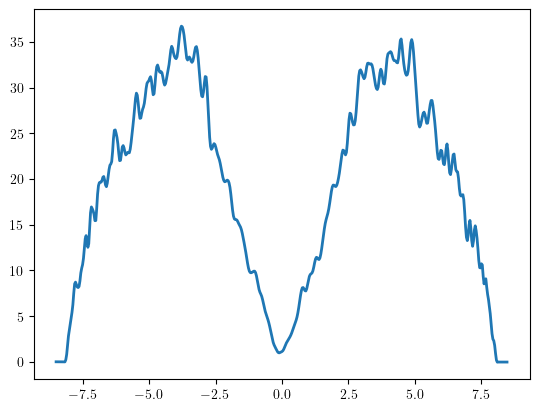

In [10]:
total=1e-9*(H+Vx+Vy)

H_ell=jcl.ell_matrix(H+total,Vx+total,Vy+total)


random_vector=jcl.random_vector_generator(H.shape[0])
M=256
sigma_xy=jcl.kpm_sigma_kubo_bastin_gpu(H_ell,'x','x',M,random_vector,'Full',None,None)

sigma_xy_mean=sigma_xy


sigma_xy_cum=sci.integrate.cumulative_simpson(2*np.pi*sigma_xy_mean[:,1]/Omega,x=sigma_xy_mean[:,0])

plt.plot(sigma_xy_mean[:-1,0],sigma_xy_cum,label=r'xy',linewidth=2)

# Haldane

In [11]:
def pb_lattice_Haldane(t=-2.7,m=0,t2=2/(3*np.sqrt(3))):

    a = 0.24595   # [nm] unit cell length
    a_cc = 0.142  # [nm] carbon-carbon distance

    lat = jpb.Lattice(
        a1=[a, 0],
        a2=[a/2, a/2 * np.sqrt(3)]
    )

    lat.add_sublattices(
        # name and position
        ('A', [0, -a_cc/2],-m),
        ('B', [0,  a_cc/2],m)
    )

    lat.add_hoppings(
        # inside the main cell
        ([0,  0], 'A', 'B', t),
        # between neighboring cells
        ([1, -1], 'A', 'B', t),
        ([0, -1], 'A', 'B', t),

        ([1, 0], 'A', 'A', t2 * 1j),
        ([0, -1], 'A', 'A', t2 * 1j),
        ([-1, 1], 'A', 'A', t2 * 1j),

        ([1, 0], 'B', 'B', t2 * -1j),
        ([0, -1], 'B', 'B', t2 * -1j),
        ([-1, 1], 'B', 'B', t2 * -1j)
    )

    return lat

32768


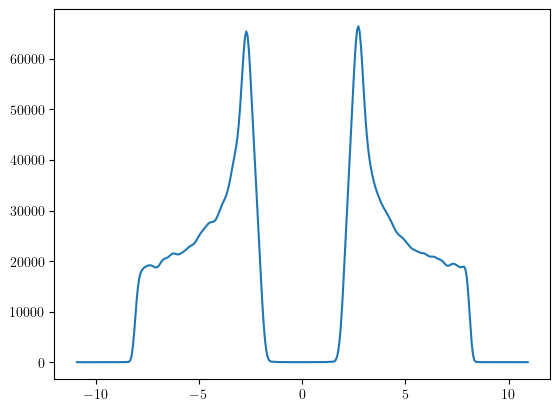

In [12]:
lat=pb_lattice_Haldane()
model=jpb.Model(lat,'real',128)

H,S,Omega,Vx,Vy=hamiltonian(model)
print(H.shape[0])
H_ell=jcl.ell_matrix(H)

dos=jcl.kpm_dos(H_ell)

plt.plot(dos[:,0],dos[:,1])



Fermi sea/Full computation, you should integrate this option to obtain the conductivity.


Time it took in the recursion : 0.4841693979979027[s]
Time it took in the summation : 0.020487447996856645[s]


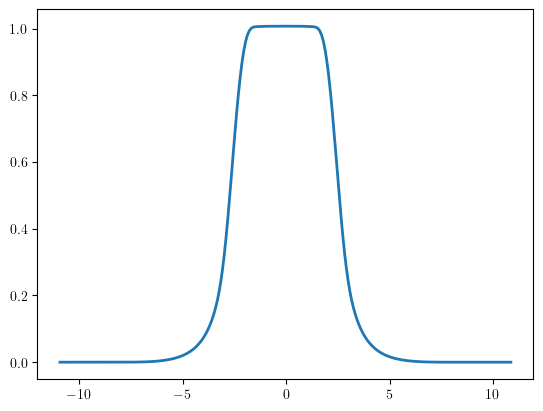

In [13]:
total=1e-9*(H+Vx+Vy)

H_ell=jcl.ell_matrix(H+total,Vx+total,Vy+total)


random_vector=jcl.random_vector_generator(H.shape[0])
M=128
sigma_xy=jcl.kpm_sigma_kubo_bastin_gpu(H_ell,'x','y',M,random_vector,'Sea',None,None)

sigma_xy_mean=sigma_xy


sigma_xy_cum=sci.integrate.cumulative_simpson(2*np.pi*sigma_xy_mean[:,1]/Omega,x=sigma_xy_mean[:,0])

plt.plot(sigma_xy_mean[:-1,0],sigma_xy_cum,label=r'xy',linewidth=2)

# Kane Mele

In [14]:
def pb_lattice_kane_mele(t=-2.7,m=0,lambda_I=- 1/(3*np.sqrt(3)) ,Bz=0):
    
    a = 0.24595   # [nm] unit cell length
    a_cc = 0.142  # [nm] carbon-carbon distance
    
    sz=np.array([[1,0],[0,-1]])

    lat = jpb.Lattice(
        a1=[a, 0],
        a2=[a/2, a/2 * np.sqrt(3)]
    )

    lat.add_sublattices(
        # name and position
        ('A', [0, -a_cc/2],-m*np.array([[1,0],[0,1]])+np.array([[Bz,0],[0,-Bz]])),
        ('B', [0,  a_cc/2],m*np.array([[1,0],[0,1]])+np.array([[Bz,0],[0,-Bz]]))
    )

    lat.add_hoppings(
        # inside the main cell
        ([0,  0], 'A', 'B', t*np.array([[1,0],[0,1]])),
        # between neighboring cells
        ([1, -1], 'A', 'B', t*np.array([[1,0],[0,1]])),
        ([0, -1], 'A', 'B', t*np.array([[1,0],[0,1]])),
        ([1, 0], 'A', 'A', lambda_I * 1j*sz),
        ([0, -1], 'A', 'A', lambda_I * 1j*sz),
        ([-1, 1], 'A', 'A', lambda_I * 1j*sz),

        ([1, 0], 'B', 'B', lambda_I * -1j*sz),
        ([0, -1], 'B', 'B', lambda_I * -1j*sz),
        ([-1, 1], 'B', 'B', lambda_I * -1j*sz)
    )

    return lat
lat=pb_lattice_kane_mele()

16384


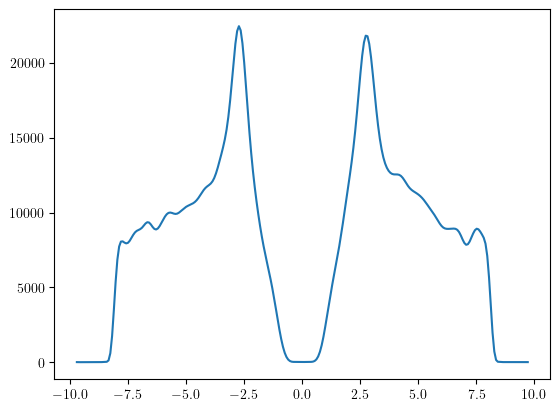

In [15]:
model=jpb.Model(lat,'real',64)

H,S,Omega,Vx,Vy=hamiltonian(model)
print(H.shape[0])
H_ell=jcl.ell_matrix(H)

dos=jcl.kpm_dos(H_ell)

plt.plot(dos[:,0],dos[:,1])


In [16]:
H,S,Omega,Vx,Vy=hamiltonian(model)

total=1e-9*(H+Vx+Vy)

H=jcl.ell_matrix(H+total,Vx+total,Vy+total)

random_vector=jcl.random_vector_generator(H.shape[0])

Vx=H.modifier(jcl.modifier_velocity,'x')
Vx_csr=jcl.ell_to_csr(Vx)

Sz_small=np.kron(np.eye(2),np.array([[0.5,0],[0,-0.5]]))

Sz=sci.sparse.block_diag((H.shape[0]//4)*[Sz_small+0j],format='csr')
Sz_Vx=Vx_csr.dot(Sz)+Sz.dot(Vx_csr)



H_csr=jcl.ell_to_csr(H)

total=1e-10*(H_csr+H.DX+H.DY+Sz_Vx)

Sz_Vx_ell=jcl.ell_matrix(Sz_Vx+total)


H=jcl.ell_matrix(H_csr+total,H.DX+total,H.DY+total)
sigma_xy=jcl.kpm_sigma_kubo_bastin_gpu(H,'x','y',M,random_vector,'Sea',None,Sz_Vx_ell)
H.Omega=Omega

Fermi sea/Full computation, you should integrate this option to obtain the conductivity.
Time it took in the recursion : 0.4732587339967722[s]
Time it took in the summation : 0.02557630799128674[s]


This is in e/2*pi not in e^2/h


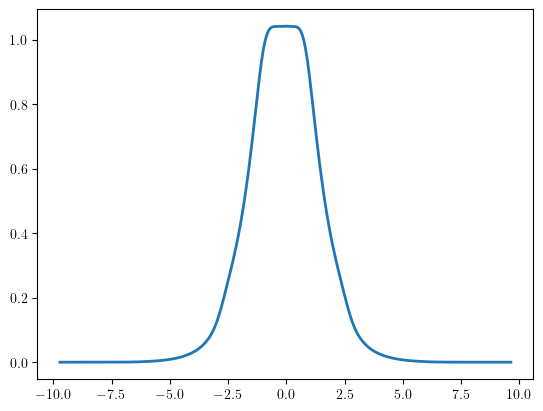

In [17]:
sigma_xy_mean=sigma_xy

print('This is in e/2*pi not in e^2/h')
sigma_xy_cum=sci.integrate.cumulative_simpson(np.pi*sigma_xy_mean[:,1]/H.Omega,x=sigma_xy_mean[:,0])

plt.plot(sigma_xy_mean[:-1,0],sigma_xy_cum,label=r'xy',linewidth=2)


# Test multiorbital square lattice

In [ ]:
def Slater_Koaster_s_px_py_pz(e,Vsss,Vsps,Vpps,Vppp):

    ### Vector normalization
    e_norm=e/np.linalg.norm(e)

    ### Building the matrix
    t_mat=np.zeros((4,4),dtype=complex)
    
    ### s-s
    t_mat[0,0]=Vsss
    ### s-p
    # s-px hopping
    t_mat[0,1]=e_norm[0]*Vsps
    t_mat[1,0]=-e_norm[0]*Vsps
    # s-py hopping
    t_mat[0,2]=e_norm[1]*Vsps
    t_mat[2,0]=-e_norm[1]*Vsps
    # s-pz hopping
    t_mat[0,3]=e_norm[2]*Vsps
    t_mat[3,0]=-e_norm[2]*Vsps
            
    ### p-p


    # px-px hopping
    t_mat[1,1]=(e_norm[0]**2*Vpps+(1-e_norm[0]**2)*Vppp)
    # px-py hopping
    t_mat[1,2]=e_norm[0]*e_norm[1]*(Vpps-Vppp)
    # px-pz hopping
    t_mat[1,3]=e_norm[0]*e_norm[2]*(Vpps-Vppp)

    # py-py hopping
    t_mat[2,2]=(e_norm[1]**2*Vpps+(1-e_norm[1]**2)*Vppp)
    # py-px hopping
    t_mat[2,1]=e_norm[0]*e_norm[1]*(Vpps-Vppp)
    # py-pz hopping
    t_mat[2,3]=e_norm[1]*e_norm[2]*(Vpps-Vppp)
    
    # pz-pz hopping
    t_mat[3,3]=(e_norm[2]**2*Vpps+(1-e_norm[2]**2)*Vppp)
    # pz-px hopping
    t_mat[3,1]=e_norm[0]*e_norm[2]*(Vpps-Vppp)
    # pz-py hopping
    t_mat[3,2]=e_norm[1]*e_norm[2]*(Vpps-Vppp)


    return t_mat


def pb_lattice_square_SK_SOC(Es=3.2,Ep=-0.5,Vsss=0.5,Vsps=0.5,Vpps=0.5,Vppp=0.2,lambda_SOC=0.1):
    """
    Default parameters are extracted from : https://doi.org/10.1103/PhysRevLett.121.086602

    """

    
    d = 2  # [A] unit cell length
    pos_A=np.array([0, 0,0])
    a1=np.array([d, 0,0])
    a2=np.array([0, d,0])
    onsites=np.diag([Es,Ep,Ep,Ep])
    # SOC part
    Lx=np.array([[0,0,0,0],[0,0,0,0],[0,0,0,-1j],[0,0,1j,0]])
    Ly=np.array([[0,0,0,0],[0,0,0,1j],[0,0,0,0],[0,-1j,0,0]])
    Lz=np.array([[0,0,0,0],[0,0,-1j,0],[0,1j,0,0],[0,0,0,0]])

    Sx=0.5*np.array([[0,1],[1,0]])
    Sy=0.5*np.array([[0,-1j],[1j,0]])
    Sz=0.5*np.array([[1,0],[0,-1]])
    L_S=2*lambda_SOC*(np.kron(Lx,Sx)+np.kron(Ly,Sy)+np.kron(Lz,Sz))

    

    # print(Slater_Koaster_s_px_py_pz((1*a1+0*a2)+pos_A-pos_A,Vsss,Vsps,Vpps,Vppp))
    # print(Slater_Koaster_s_px_py_pz((0*a1+1*a2)+pos_A-pos_A,Vsss,Vsps,Vpps,Vppp))
    
    # create a simple 2D lattice with vectors a1 and a2
    lattice = jpb.Lattice(a1, a2)
    lattice.add_sublattices(
        ('A', pos_A ,np.kron(onsites,np.eye(2))+L_S+),  # add an atom called 'A' at position [0, 0]
    )
    lattice.add_hoppings(
        # (relative_index, from_sublattice, to_sublattice, energy)
        ## Same lattice
        ([1, 0], 'A', 'A', np.kron(Slater_Koaster_s_px_py_pz((1*a1+0*a2)+pos_A-pos_A,Vsss,Vsps,Vpps,Vppp),np.eye(2))),
        ([0, 1], 'A', 'A', np.kron(Slater_Koaster_s_px_py_pz((0*a1+1*a2)+pos_A-pos_A,Vsss,Vsps,Vpps,Vppp),np.eye(2))),

 )

    return lattice


In [101]:
lat=pb_lattice_square_SK_SOC(Es=3.2,Ep=-0.5,Vsss=-0.5,Vsps=0.5,Vpps=0.5,Vppp=-0.2,lambda_SOC=0.05)
model=jpb.Model(lat,'real',2)
H,S,Omega,Vx,Vy=hamiltonian(model,True)

D = 1j*Vy - (1j*Vy).getH()

print("max error =", np.max(np.abs(D.data)) if D.nnz else 0)
print("nnz =", D.nnz)

max error = 0
nnz = 0


131072


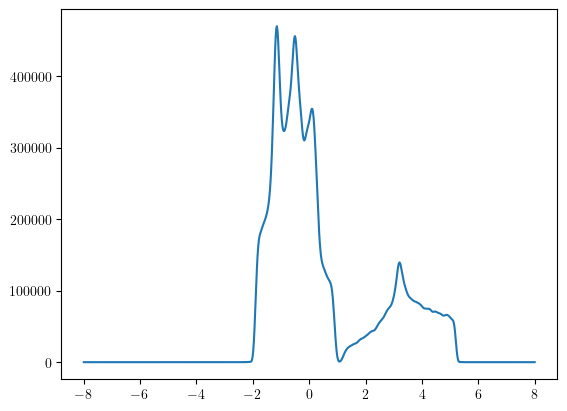

In [103]:
lat=pb_lattice_square_SK_SOC(Es=3.2,Ep=-0.5,Vsss=-0.5,Vsps=0.5,Vpps=0.5,Vppp=-0.2,lambda_SOC=0.05)
model=jpb.Model(lat,'real',128)

H,S,Omega,Vx,Vy=hamiltonian(model,True)

print(H.shape[0])
H_ell=jcl.ell_matrix(H)
H_ell.bounds=np.array([-8,8])

dos=jcl.kpm_dos(H_ell)

plt.plot(dos[:,0],dos[:,1])

In [110]:
M=64
model=jpb.Model(lat,'real',128)

H,S,Omega,Vx,Vy=hamiltonian(model, True)
random_vector=jcl.random_vector_generator(H.shape[0])

total=1e-9*(H+Vx+Vy)

H=jcl.ell_matrix(H+total,Vx+total,Vy+total)



Vx=H.modifier(jcl.modifier_velocity,'x')
Vx_csr=jcl.ell_to_csr(Vx)

Lz_small=np.kron(np.array([[0,0,0,0],[0,0,-1j,0],[0,1j,0,0],[0,0,0,0]]),np.eye(2))
# Lz_small=np.kron(np.eye(2),np.array([[0,0,0,0],[0,0,-1j,0],[0,1j,0,0],[0,0,0,0]]))
# Lz_small=np.kron(np.eye(2),np.array([[0,0,0,0],[0,0,-1j,0],[0,1j,0,0],[0,0,0,0]]))
Lz=sci.sparse.block_diag((H.shape[0]//8)*[Lz_small],format='csr')
Lz_Vx=Vx_csr.dot(Lz)+Lz.dot(Vx_csr)



H_csr=jcl.ell_to_csr(H)

total=1e-9*(H_csr+H.DX+H.DY+Lz_Vx)

Lz_Vx_ell=jcl.ell_matrix(Lz_Vx+total)


H=jcl.ell_matrix(H_csr+total,H.DX+total,H.DY+total)
sigma_xy=jcl.kpm_sigma_kubo_bastin_gpu(H,'x','y',M,random_vector,'Sea',None,Lz_Vx_ell)
H.Omega=Omega

Fermi sea/Full computation, you should integrate this option to obtain the conductivity.
Time it took in the recursion : 0.966307335998863[s]
Time it took in the summation : 0.006873919992358424[s]


In [63]:
model=jpb.Model(lat,'k',64)

solver=jpb.Solver(model)

mu_vec=np.linspace(-5,7.5,101)

Lz=np.kron(np.array([[0,0,0,0],[0,0,-1j,0],[0,1j,0,0],[0,0,0,0]]),np.eye(2))

kubo_surf,kubo_sea=solver.kubo(mu_vec,broadening=0.5,Temp=0,operator=Lz)

100%|██████████| 4096/4096 [00:45<00:00, 89.21it/s]


This is in e/2*pi not in e^2/h


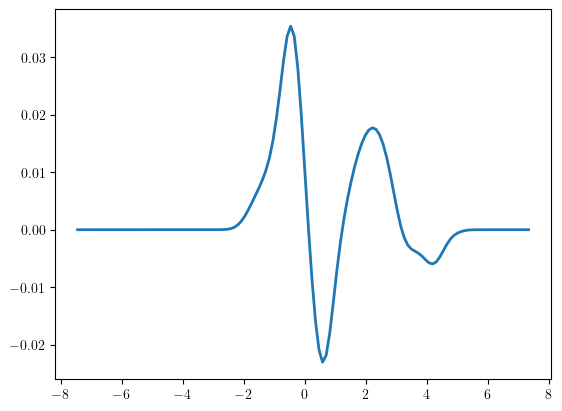

In [111]:
sigma_xy_mean=sigma_xy

print('This is in e/2*pi not in e^2/h')
sigma_xy_cum=sci.integrate.cumulative_simpson(np.pi*sigma_xy_mean[:,1]/H.Omega,x=sigma_xy_mean[:,0])

plt.plot(sigma_xy_mean[:-1,0],-sigma_xy_cum,label=r'xy',linewidth=2)
# plt.plot(mu_vec,-0.01*kubo_sea)

# Bismuthene

In [112]:
def Slater_Koaster(e,Vpps,Vppp):
    print('Repasar con el de abajo porque no se si este modelo está bien.')
    ### Vector normalization
    e_norm=e/np.linalg.norm(e)

    ### Building the matrix
    t_mat=np.zeros((2,2),dtype=complex)
    
    # px-px hopping
    t_mat[0,0]=e_norm[0]**2*Vpps+(1-e_norm[0]**2)*Vppp
    # px-py hopping
    t_mat[0,1]=e_norm[0]*e_norm[1]*(Vpps-Vppp)
    # py-px hopping
    t_mat[1,0]=np.conj(t_mat[0,1])
    # py-py hopping
    t_mat[1,1]=e_norm[1]**2*Vpps+(1-e_norm[1]**2)*Vppp

    return t_mat
def pb_lattice_bismuthene_SOC_2atoms(Vpps=1.815,Vppp=-0.315,m=0.2,lambda_i=0.435):
    a = 0.24595   # [nm] unit cell length
    a_cc = 0.142  # [nm] carbon-carbon distance
    
    # Define the lattice vectors
    a1=[a, 0]
    a2=[a/2, a/2 * np.sqrt(3)]
    # Distance of the three different that the hoppings are going to
    e1=np.array([0,a_cc])
    e2=e1+a1-a2
    e3=e1-a2
    # Intrinsic soc
    Lz=np.array([[0,-1j],[1j,0]])
    Sz=np.array([[1,0],[0,-1]])


    lat = jpb.Lattice(a1,a2)

    lat.add_sublattices(('A', [0, -a_cc/2],0.5*m*np.eye(4)+lambda_i*np.kron(Lz,Sz)),
                        ('B', [0,  a_cc/2],-0.5*m*np.eye(4)+lambda_i*np.kron(Lz,Sz)))
    lat.add_hoppings(
        # inside the main cell
        ([0,  0], 'A', 'B',np.kron(Slater_Koaster(e1,Vpps,Vppp),np.eye(2))),
        ([1, -1], 'A', 'B',np.kron(Slater_Koaster(e2,Vpps,Vppp),np.eye(2))),
        ([0, -1], 'A', 'B',np.kron(Slater_Koaster(e3,Vpps,Vppp),np.eye(2)))

    )
    return lat

In [113]:
lattice=pb_lattice_bismuthene_SOC_2atoms(Vpps=1.815,Vppp=-0.315,m=0.2,lambda_i=0.435)

model=jpb.Model(lattice,'k',64)

solver=jpb.Solver(model)


sz=np.kron(np.eye(2),np.kron(np.eye(2),np.array([[0.5,0],[0,-0.5]])))

mu_vec=np.linspace(-4,4.101)

kubo_surf,kubo_sea=solver.kubo(mu_vec,broadening=0.5,Temp=0,operator=sz)

Repasar con el de abajo porque no se si este modelo está bien.
Repasar con el de abajo porque no se si este modelo está bien.
Repasar con el de abajo porque no se si este modelo está bien.



100%|██████████| 4096/4096 [00:24<00:00, 167.66it/s]


In [119]:
M=256
nx=128
ny=nx
model=jpb.Model(lat,'real',128)
H,S,Omega,Vx,Vy=hamiltonian(model, True)


H=jcl.ell_matrix(H+total,Vx+total,Vy+total)
random_vector=jcl.random_vector_generator(H.shape[0])

Vx=H.modifier(jcl.modifier_velocity,'x')
Vx_csr=jcl.ell_to_csr(Vx)

Sz_small=np.kron(np.array([[0.5,0],[0,-0.5]]),np.eye(2))

Sz=sci.sparse.block_diag((H.shape[0]//4)*[Sz_small+0j],format='csr')
Sz_Vx=Vx_csr.dot(Sz)+Sz.dot(Vx_csr)



H_csr=jcl.ell_to_csr(H)

total=1e-10*(H_csr+H.DX+H.DY+Sz_Vx)

Sz_Vx_ell=jcl.ell_matrix(Sz_Vx+total)


H=jcl.ell_matrix(H_csr+total,H.DX+total,H.DY+total)
sigma_xy=jcl.kpm_sigma_kubo_bastin_gpu(H,'x','y',M,random_vector,'Sea',None,Sz_Vx_ell)
H.Omega=Omega

Fermi sea/Full computation, you should integrate this option to obtain the conductivity.
Time it took in the recursion : 3.2617629510059487[s]
Time it took in the summation : 0.08735232999606524[s]


This is in e/2*pi not in e^2/h


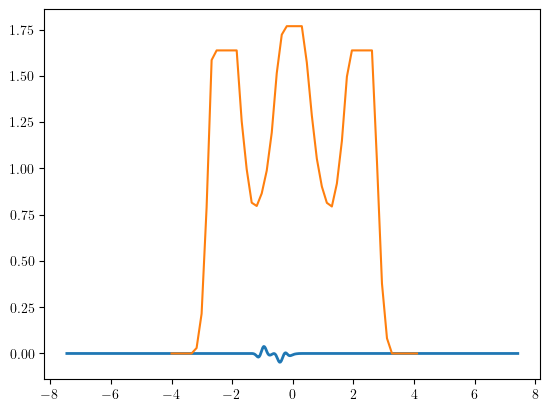

In [120]:
sigma_xy_mean=sigma_xy

print('This is in e/2*pi not in e^2/h')
sigma_xy_cum=sci.integrate.cumulative_simpson(np.pi*sigma_xy_mean[:,1]/H.Omega,x=sigma_xy_mean[:,0])

plt.plot(sigma_xy_mean[:-1,0],-sigma_xy_cum,label=r'xy',linewidth=2)
plt.plot(mu_vec,-kubo_sea)